In [2]:
import pandas as pd
warehouse_slots = []

rows = ["A", "B", "C", "D", "E"]

for i, row in enumerate(rows):
    for j in range(1, 6):
        warehouse_slots.append({
            "slot": f"{row}{j}",
            "x": i,
            "y": j - 1
        })

warehouse_slots = pd.DataFrame(warehouse_slots)

warehouse_slots.head(10)

,slot,x,y
0,A1,0,0
1,A2,0,1
2,A3,0,2
3,A4,0,3
4,A5,0,4
5,B1,1,0
6,B2,1,1
7,B3,1,2
8,B4,1,3
9,B5,1,4


In [3]:
print(warehouse_slots)

   slot  x  y
0    A1  0  0
1    A2  0  1
2    A3  0  2
3    A4  0  3
4    A5  0  4
5    B1  1  0
6    B2  1  1
7    B3  1  2
8    B4  1  3
9    B5  1  4
10   C1  2  0
11   C2  2  1
12   C3  2  2
13   C4  2  3
14   C5  2  4
15   D1  3  0
16   D2  3  1
17   D3  3  2
18   D4  3  3
19   D5  3  4
20   E1  4  0
21   E2  4  1
22   E3  4  2
23   E4  4  3
24   E5  4  4


In [4]:
print("Total warehouse slots:", len(warehouse_slots))

Total warehouse slots: 25


In [6]:
import pandas as pd

product_base = pd.read_csv(
    "../data/processed/business_slotting_recommendations.csv"
)

print(product_base.shape)
print(product_base.columns.tolist())

(3922, 12)
['StockCode', 'order_frequency', 'total_quantity', 'avg_quantity_per_order', 'related_product_count', 'cluster_name', 'recommended_zone', 'distance_from_packing', 'picking_priority', 'current_distance', 'distance_saved', 'business_recommendation']


In [7]:
print(product_base[["StockCode"]].head())

  StockCode
0    85099B
1    85123A
2     22197
3     84879
4     21212


In [8]:
product_base = product_base.reset_index(drop=True)

product_base["current_slot"] = [
    warehouse_slots.iloc[i % len(warehouse_slots)]["slot"]
    for i in range(len(product_base))
]

In [9]:
slot_coordinates = warehouse_slots.set_index("slot")[
    ["x", "y"]
].to_dict("index")

In [10]:
product_base["current_x"] = product_base["current_slot"].map(
    lambda x: slot_coordinates[x]["x"]
)

product_base["current_y"] = product_base["current_slot"].map(
    lambda x: slot_coordinates[x]["y"]
)

In [11]:
product_base[
    [
        "StockCode",
        "current_slot",
        "current_x",
        "current_y"
    ]
].head(20)

,StockCode,current_slot,current_x,current_y
0,85099B,A1,0,0
1,85123A,A2,0,1
2,22197,A3,0,2
3,84879,A4,0,3
4,21212,A5,0,4
5,47566,B1,1,0
6,23084,B2,1,1
7,20725,B3,1,2
8,84077,B4,1,3
9,22423,B5,1,4


In [12]:
packing_x = 0
packing_y = 0

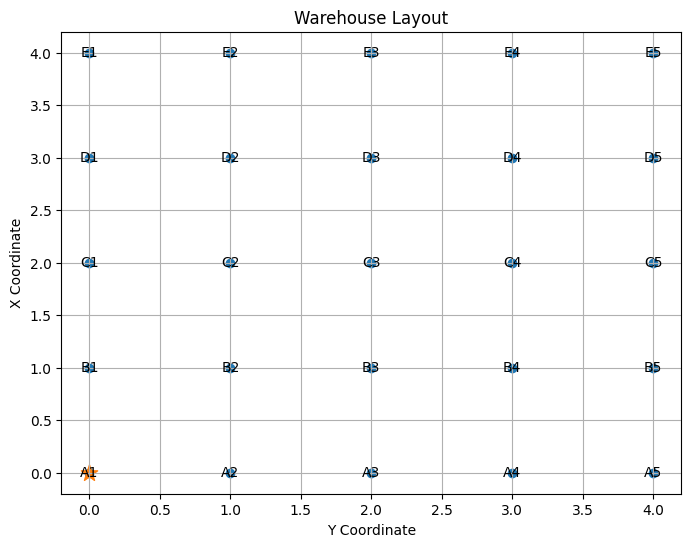

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    warehouse_slots["y"],
    warehouse_slots["x"]
)

for _, row in warehouse_slots.iterrows():
    plt.text(
        row["y"],
        row["x"],
        row["slot"],
        ha="center",
        va="center"
    )

plt.scatter(
    packing_y,
    packing_x,
    s=150,
    marker="*"
)

plt.title("Warehouse Layout")
plt.xlabel("Y Coordinate")
plt.ylabel("X Coordinate")

plt.grid()
plt.show()

In [14]:
warehouse_slots.to_csv(
    "../data/processed/warehouse_slots.csv",
    index=False
)